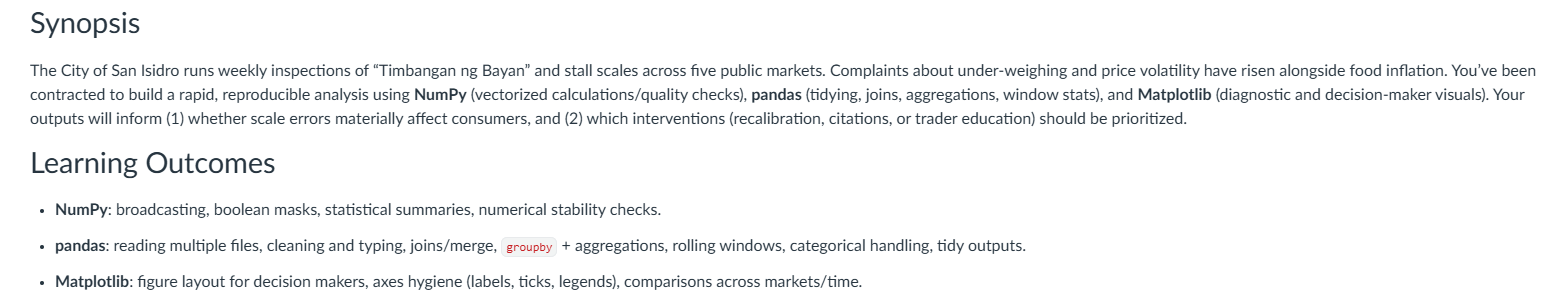

In [7]:
#Libraries needed: Pandas, Numpy, Matplotlib (Run first)
%pip install pandas
%pip install numpy
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\JosefN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\JosefN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\JosefN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# csv dataset generator

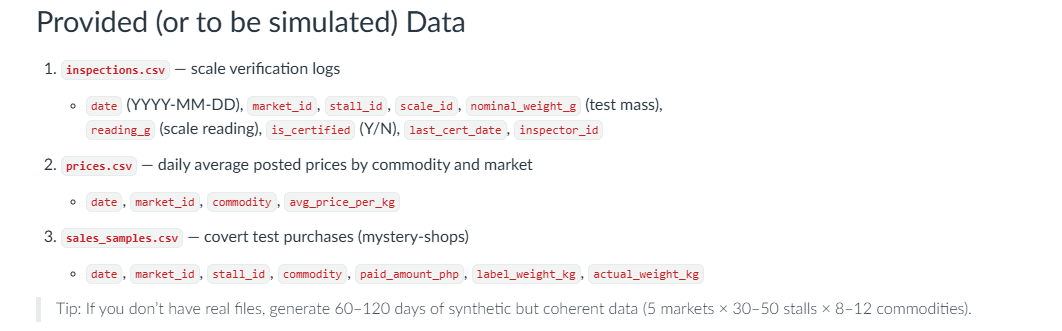

In [13]:
import numpy as np
import pandas as pd

np.random.seed(1)

'For generating inspections.csv'

#random amount of days chosen between 60-120
days = np.random.randint(60, 121)

# Inspection dates, starts at 2026-01-01, weekly every Thursday
date = pd.date_range(start='2026-01-01', periods=days, freq='W-THU')

#IDs
market_id = np.random.randint(1, 6, size=days) #Market ID - 1-5 Markets
stall_id = np.random.randint(30, 51,size=days) #Stall ID - 30-50 Stalls
scale_id = np.random.randint(1, 3, size=days) #Scale ID - 1 or 2 Scales per Stall

#certifcation date logic

inspector_id = np.random.randint(1, 6, size=days) #Inspector ID - 1-5 Inspectors

inspector_certificate = pd.to_datetime('2026-01-01') - pd.to_timedelta(np.random.randint(12, 30, size=6), unit="D") #Create set dates for inspector certificates

last_cert_check = pd.DatetimeIndex(inspector_certificate[inspector_id]) #assign inspector certificate values to inspector id

check_cert = (date - last_cert_check).days #calculate if its still valid

is_certified = np.where(check_cert <= 548, "Y", "N") #Check if inspector last cert date is within  548 days (1.5 years), else expired

last_cert_date = last_cert_check.strftime("%Y-%m-%d") #turn last cert check to string with format year-month-day

#Convert date as data to make sure it can run
date_as_data = date.strftime("%Y-%m-%d")


#weight calibration
#Nominal Weight tests - 100g, 250g, 500g, 1000g
nominal_weight_g = np.random.choice([100, 250, 500, 1000], size=days)

#Error percentage
error_perc = np.random.uniform(-0.02, 0.02, size=days)

#Reading Weight from using scale, difference varies based on error percentage
reading_g = np.round(nominal_weight_g * (1 + error_perc), 2)

#Create dataframe
df_inspections = pd.DataFrame({
    "date": date_as_data,
    "market_id": market_id,
    "stall_id": stall_id,
    "scale_id": scale_id,
    "nominal_weight_g": nominal_weight_g,
    "reading_g": reading_g,
    "is_certified": is_certified,
    "last_cert_date": last_cert_date,
    "inspector_id": inspector_id
})

# 7. Save to CSV
df_inspections.to_csv("inspections.csv", index=False)
print("inspections.csv created")
print(df_inspections.head())


inspections.csv created
         date  market_id  stall_id  scale_id  nominal_weight_g  reading_g  \
0  2026-01-01          4        43         1               500     493.05   
1  2026-01-08          5        40         2               500     502.44   
2  2026-01-15          1        47         1               100     100.18   
3  2026-01-22          2        37         2               500     503.08   
4  2026-01-29          4        40         1               100      98.58   

  is_certified last_cert_date  inspector_id  
0            Y     2025-12-11             1  
1            Y     2025-12-09             5  
2            Y     2025-12-07             2  
3            Y     2025-12-09             5  
4            Y     2025-12-07             2  


Prices.csv generator

variables needed: date, market_id, commodity, avg_price_per_kg

In [14]:
import numpy as np
import pandas as pd

np.random.seed(2)

'For generating prices.csv'

#using the code already written in inspecctions.csv
df_inspections = pd.read_csv("inspections.csv")

# Extract the exact dates and count from inspections
inspectiondate = pd.to_datetime(df_inspections['date']).unique()
days = len(inspectiondate) #makes sure it has the exact same days as inspections.csv

date = (inspectiondate + pd.to_timedelta(np.random.randint(-3, 3, size=days), unit='D')).strftime('%Y-%m-%d')
market_id = df_inspections['market_id'].values # Match market ID too


#commodities logic
#commodity list, 8-12 choices
commodity_list = [ 'Rice', 'Chicken', 'Pork', 'Beef', 
                  'Bangus', 'Tomatoes', 'Onions', 'Garlic', 
                  'Eggplant', 'Cabbage', 'Carrots', 'Potatoes', 
                  'Tilapia', 'Ginger']

commodity_amount = np.random.randint(8, 13) #commodity_amount, choose random amount of commodities in the list

#code for choosing which commodities are chosen, replace=False for no duplicates and keep all distinct
commodities_chosen = np.random.choice(commodity_list, size=commodity_amount, replace=False)

#Assign the chosen commodities to your rows
commodity = np.random.choice(commodities_chosen, size=days)

#created minmax bound for avg_price_per_kg so each item price is different and actually makes sense for a synthetic

commodity_price_minmax = {
    'Rice': (45.0, 60.0),
    'Chicken': (180.0, 220.0),
    'Pork': (300.0, 380.0),
    'Beef': (350.0, 450.0),
    'Bangus': (160.0, 220.0),
    'Tomatoes': (60.0, 120.0),
    'Onions': (80.0, 150.0),
    'Garlic': (100.0, 180.0),
    'Eggplant': (60.0, 90.0),
    'Cabbage': (80.0, 140.0),
    'Carrots': (90.0, 150.0),
    'Potatoes': (90.0, 140.0),
    'Tilapia': (120.0, 160.0),
    'Ginger': (100.0, 160.0)
}

#pull bounds, commodity_price_minmax(dictionary)[x][0] to call min value, [x][1] to call for max, 
#for x in commodity so it calls for each name in list
minprice = [commodity_price_minmax[x][0] for x in commodity]
maxprice = [commodity_price_minmax[x][1] for x in commodity]

#calculate average price per kg from each unique commodity
avg_price_per_kg = np.round(np.random.uniform(minprice, maxprice), 2)

df_prices = pd.DataFrame({
    'date': date,
    'market_id': market_id,
    'commodity': commodity,
    'avg_price_per_kg': avg_price_per_kg
})

df_prices.to_csv("prices.csv", index=False)
print("Generated prices.csv")
print(df_prices.head())

Generated prices.csv
         date  market_id commodity  avg_price_per_kg
0  2025-12-29          4   Carrots            138.77
1  2026-01-10          5  Potatoes            117.29
2  2026-01-12          1      Pork            301.46
3  2026-01-22          2    Onions             81.13
4  2026-01-28          4    Bangus            216.10


Sales_samples.csv generator

variables needed: date, market_id, stall_id, commodity, paid_amount_php, label_weight_kg, actual_weight_kg

In [15]:
import numpy as np
import pandas as pd

np.random.seed(3)

'For generating sales_samples.csv'

df_inspections = pd.read_csv("inspections.csv")
df_prices = pd.read_csv("prices.csv")


date = df_prices['date'].unique()
market_id = df_inspections['market_id'].values 
stall_id = df_inspections['stall_id'].values
commodity = df_prices['commodity'].values

label_weight_kg = np.random.choice(
    [0.5, 1.0, 1.5, 2.0],
    size=len(df_inspections))

error_perc = np.random.uniform(-0.0075, 0.0025, size=len(df_inspections))
actual_weight_kg = np.round(label_weight_kg * (1 + error_perc), 3)

df_sales = pd.DataFrame({

    'date': date,

    'market_id': market_id,

    'stall_id': stall_id,

    'commodity': commodity,

    'label_weight_kg': label_weight_kg,

    'actual_weight_kg': actual_weight_kg
})
price_lookup = df_prices[['date', 'market_id', 'commodity', 'avg_price_per_kg']]

df_sales = df_sales.merge(
    price_lookup,
    on=['date', 'market_id', 'commodity'],
    how='left'
)

paid_amount_php = np.round(
    df_sales['label_weight_kg'] *
    df_sales['avg_price_per_kg'],
    2)

df_sales['paid_amount_php'] = paid_amount_php
df_sales = df_sales[
       ['date',
        'market_id',
        'stall_id',
        'commodity',
        'paid_amount_php',
        'label_weight_kg',
        'actual_weight_kg']]
df_sales.to_csv("sales_samples.csv", index=False)
print("sales_samples.csv created")
print(df_sales.head())


sales_samples.csv created
         date  market_id  stall_id commodity  paid_amount_php  \
0  2025-12-29          4        43   Carrots           208.16   
1  2026-01-10          5        40  Potatoes            58.64   
2  2026-01-12          1        47      Pork           301.46   
3  2026-01-22          2        37    Onions           162.26   
4  2026-01-28          4        40    Bangus           108.05   

   label_weight_kg  actual_weight_kg  
0              1.5             1.494  
1              0.5             0.497  
2              1.0             1.000  
3              2.0             1.986  
4              0.5             0.500  


# Part A: NumPy Mini-Writeup

The fraction of inspected scales outside the ±0.5% tolerance varies across the five markets. Market 1 had the highest fraction at **85.71% (18 out of 21 inspections)**, followed by Market 4 at **76.47% (13 out of 17)**, Market 2 at **73.91% (17 out of 23)**, Market 3 at **71.43% (10 out of 14)**, and Market 5 at **63.64% (14 out of 22)**. This shows that a substantial fraction of the inspected scales in every market were outside the specified tolerance.

Based on the scale inspection results, **consumer risk is highest in Market 1**. It had the highest outside-tolerance fraction at **85.71%** and also the highest under-weighing rate at **47.62% (10 out of 21 inspections)**. This is particularly important for consumers because under-weighing means the scale reading is lower than the actual amount expected for the nominal test weight. Therefore, Market 1 should be prioritized for further inspection and possible recalibration.


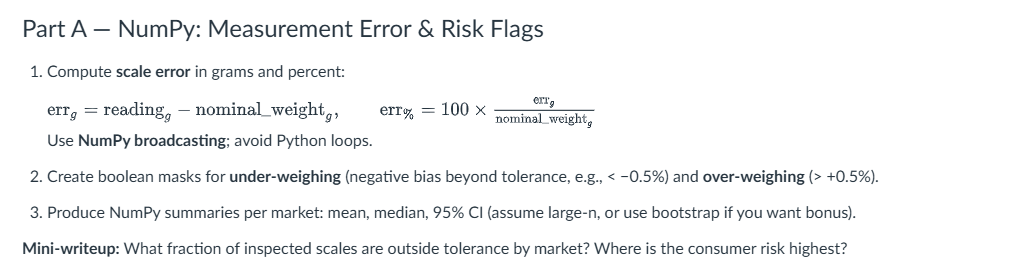

In [17]:
import numpy as np
import pandas as pd

df = pd.read_csv("inspections.csv")

print(df.head())
print(df.shape)

# Calculate scale error
error_g = df["reading_g"].to_numpy() - df["nominal_weight_g"].to_numpy()
error_pct = (error_g / df["nominal_weight_g"].to_numpy()) * 100

print("Error in grams:")
print(error_g[:5])

print("Error in percent:")
print(error_pct[:5])

# Create masks for weighing errors
under_mask = error_pct < -0.5
over_mask = error_pct > 0.5
outside_mask = under_mask | over_mask

print("Under-weighing:")
print(under_mask[:10])

print("Over-weighing:")
print(over_mask[:10])

print("Outside tolerance:")
print(outside_mask[:10])

# Calculate mean and median error per market
market_ids = df["market_id"].to_numpy()
markets = np.unique(market_ids)

market_mask = market_ids[:, np.newaxis] == markets[np.newaxis, :]
market_errors = np.where(market_mask, error_pct[:, np.newaxis], np.nan)

mean_error = np.nanmean(market_errors, axis=0)
median_error = np.nanmedian(market_errors, axis=0)

print("Markets:", markets)
print("Mean error per market:", mean_error)
print("Median error per market:", median_error)

# Calculate 95% confidence interval
n = np.sum(~np.isnan(market_errors), axis=0)
std_error = np.nanstd(market_errors, axis=0, ddof=1) / np.sqrt(n)

margin_error = 1.96 * std_error

ci_lower = mean_error - margin_error
ci_upper = mean_error + margin_error

print("95% CI lower:", ci_lower)
print("95% CI upper:", ci_upper)

# Calculate fraction of inspections outside tolerance per market
outside_by_market = np.where(market_mask, outside_mask[:, np.newaxis], False)

outside_count = np.sum(outside_by_market, axis=0)
total_count = np.sum(market_mask, axis=0)

outside_fraction = outside_count / total_count
outside_percentage = outside_fraction * 100

print("Inspections outside tolerance:", outside_count)
print("Total inspections per market:", total_count)
print("Fraction outside tolerance:", outside_fraction)
print("Percentage outside tolerance:", outside_percentage)

# Identify markets with the highest and lowest error
highest_outside_market = markets[np.argmax(outside_percentage)]
highest_mean_market = markets[np.argmax(mean_error)]
lowest_mean_market = markets[np.argmin(mean_error)]

print("Market with highest outside-tolerance percentage:",
      highest_outside_market)

print("Market with highest mean error:",
      highest_mean_market)

print("Market with lowest mean error:",
      lowest_mean_market)

# Calculate under-weighing and over-weighing per market
under_by_market = np.where(market_mask, under_mask[:, np.newaxis], False)
over_by_market = np.where(market_mask, over_mask[:, np.newaxis], False)

under_count = np.sum(under_by_market, axis=0)
over_count = np.sum(over_by_market, axis=0)

under_percentage = (under_count / total_count) * 100
over_percentage = (over_count / total_count) * 100

print("Under-weighing count:", under_count)
print("Over-weighing count:", over_count)
print("Under-weighing percentage:", under_percentage)
print("Over-weighing percentage:", over_percentage)

# Create final market summary
summary = np.column_stack((
    markets,
    mean_error,
    median_error,
    ci_lower,
    ci_upper,
    outside_percentage,
    under_percentage,
    over_percentage
))

print("\nFinal Market Summary:")
print("Market | Mean | Median | CI Lower | CI Upper | Outside % | Under % | Over %")

for row in summary:
    print(
        f"{int(row[0])} | "
        f"{row[1]:.2f} | "
        f"{row[2]:.2f} | "
        f"{row[3]:.2f} | "
        f"{row[4]:.2f} | "
        f"{row[5]:.2f}% | "
        f"{row[6]:.2f}% | "
        f"{row[7]:.2f}%"
    )


         date  market_id  stall_id  scale_id  nominal_weight_g  reading_g  \
0  2026-01-01          4        43         1               500     493.05   
1  2026-01-08          5        40         2               500     502.44   
2  2026-01-15          1        47         1               100     100.18   
3  2026-01-22          2        37         2               500     503.08   
4  2026-01-29          4        40         1               100      98.58   

  is_certified last_cert_date  inspector_id  
0            Y     2025-12-11             1  
1            Y     2025-12-09             5  
2            Y     2025-12-07             2  
3            Y     2025-12-09             5  
4            Y     2025-12-07             2  
(97, 9)
Error in grams:
[-6.95  2.44  0.18  3.08 -1.42]
Error in percent:
[-1.39   0.488  0.18   0.616 -1.42 ]
Under-weighing:
[ True False False False  True False  True False False  True]
Over-weighing:
[False False False  True False  True False False  True Fa

# Part B: Pandas Mini-Writeup

Which market–commodity pairs show the greatest expected losses? Are uncertified scales the main driver or are certified ones drifting?

The market-commodity pairs with the greatest expected losses are concentrated in Market 3 Beef, with an expected loss of 2.79 PHP, Market 3 Chicken with an expected loss of 2.38 PHP, and Market 1 Bangus with an expected loss of 2.13 PHP. Uncertified scales are not the main driver, certified scales are the ones drifting, with the highest lost pairs having an uncertified share of 0.0, yet exhibit negative median percentages, proving that systematic calibration drift in officially certified scales is the primary source of financial loss.



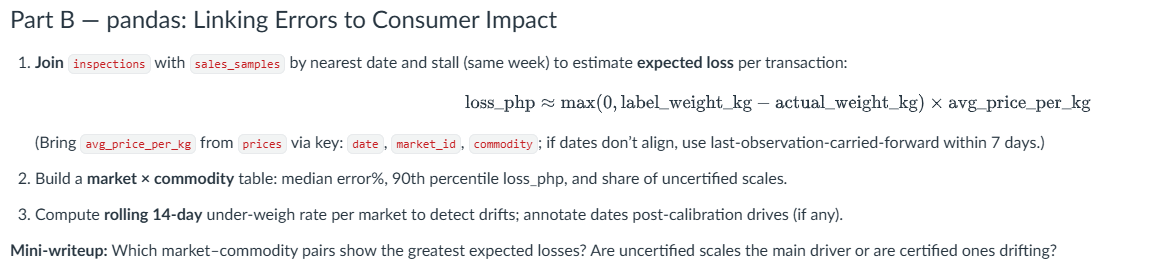

In [18]:
import numpy as np 
import pandas as pd

#load the datasets
inspections = pd.read_csv("inspections.csv")
prices = pd.read_csv("prices.csv")
sales_samples = pd.read_csv("sales_samples.csv")

#set date column as datetime, then sort the values so it doesnt error (IMPORTANT)
for df in [inspections, prices, sales_samples]:
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values("date", inplace=True)


'''
Join inspections with sales_samples by nearest date and stall (same week) 
to estimate expected loss per transaction
'''

inspections_sales_merge = pd.merge_asof(sales_samples, inspections, on="date",
    by=["stall_id", "market_id"], direction="nearest", tolerance=pd.Timedelta("7 days"))


'''
Bring avg_price_per_kg from prices via key: date, market_id, commodity;
if dates don’t align,use last‐observation‐carried‐forward within 7 days
'''

all_merge = pd.merge_asof(inspections_sales_merge, prices, on="date", 
    by=["market_id", "commodity"], direction="backward", tolerance=pd.Timedelta("7 days"))

#loss_php formula - max(0, label_weight_kg - actual_weight_kg) * avg_price_per_kg
all_merge["loss_php"] = np.maximum(0, all_merge["label_weight_kg"] - all_merge["actual_weight_kg"]) * all_merge["avg_price_per_kg"]

'''
Market X Commodity Table
Median Error%, 90th percentile loss_php, share of uncertified scales
'''

#calculate error% you need it for market x commodity table
all_merge["error_weight_perc"] = ((all_merge["actual_weight_kg"] - all_merge["label_weight_kg"]) / all_merge["label_weight_kg"]) * 100

#Create the Market x Commodity Table
market_commodity_table = (all_merge.groupby(["market_id", "commodity"])
        .agg(median_error_perc=("error_weight_perc", "median"), 
        loss_php_90th=("loss_php", lambda x: x.quantile(0.90)),
        uncertified_share=("is_certified", lambda x: (x == "N").mean())
        )
        .round({
        "median_error_perc": 2,
        "loss_php_90th": 2,
        "uncertified_share": 2
    })
        )

# Set options to show all rows and columns
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print(market_commodity_table)


#Compute rolling 14-day under-weigh rate per market to detect drifts;
#annotate dates post-calibration drives (if any).

#create column "is under-weigh"
all_merge["is_under_weigh"] = all_merge["actual_weight_kg"] < all_merge["label_weight_kg"]


#set date as index so 14 day rolling rate works right and doesn't explode
rollingrate = all_merge.set_index("date").sort_index()

#compute the rolling 14-day under-weigh rate per market
market_rolling_rate = (
    rollingrate.groupby("market_id")["is_under_weigh"]
    .rolling("14D")
    .mean()
)

print(market_rolling_rate)


                     median_error_perc  loss_php_90th  uncertified_share
market_id commodity                                                     
1         Bangus                 -0.62           2.13               0.00
          Beef                   -0.05           1.62               0.00
          Cabbage                -0.10           0.48               1.00
          Carrots                -0.29           1.11               0.50
          Chicken                -0.20           0.71               0.00
          Onions                 -0.43           0.54               0.00
          Pork                    0.03           0.00               0.50
          Potatoes               -0.20           0.58               0.00
          Tilapia                -0.23           0.54               0.50
2         Bangus                 -0.50           1.25               0.00
          Beef                    0.27           0.00               0.00
          Cabbage                 0.05           0.

# Part C: Pandas Mini-Writeup

In one paragraph, argue for a prioritized action plan with evidence from your plots.

The City of San Isidro should first focus on markets with consistently high 14-day under-weigh rates, as shown in the rolling rate plot, because these markets show more frequent weighing problems. Next, the heatmap should be used to identify market and commodity combinations with higher median expected losses so inspections can focus on areas that may cause greater consumer losses. Finally, the before-and-after calibration plot can be used to check if under-weighing errors improve after calibration. This action plan prioritizes monitoring, inspections, and calibration in areas where the plots show the greatest need.

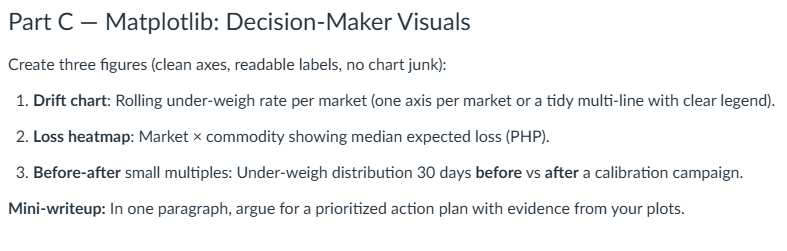

Inspections: (97, 9)
Prices: (97, 4)
Sales samples: (97, 7)


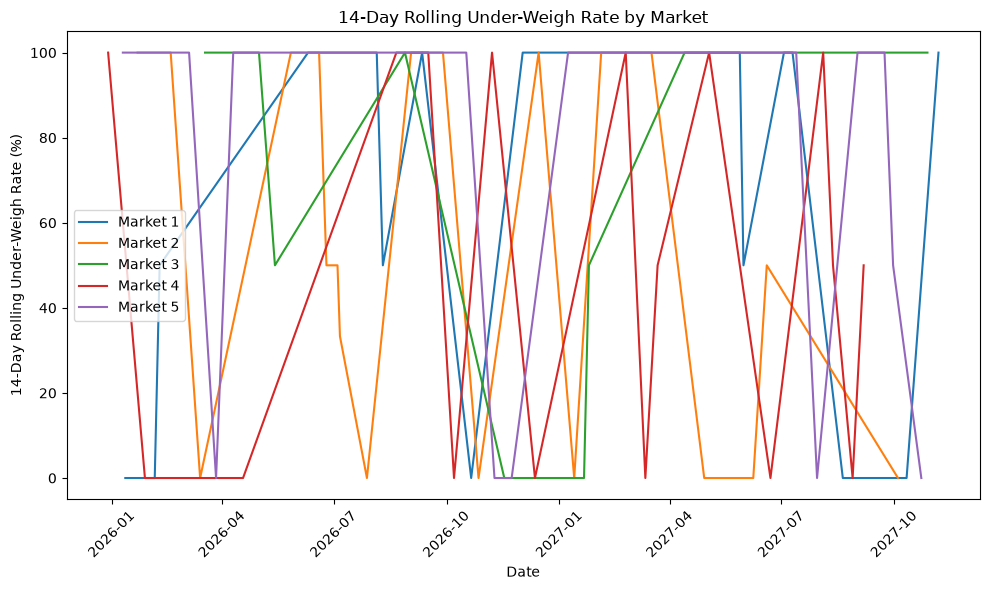


Median Expected Loss Table:
commodity   Bangus     Beef  Cabbage   Carrots   Chicken   Garlic   Onions  \
market_id                                                                    
1          1.62310  0.43485  0.26394  0.700270  0.393520      NaN  0.42620   
2          0.96815  0.00000  0.00000  0.678530  0.107715  0.40350  0.10407   
3          0.00000  1.07925  0.63336  1.730195  1.323350  1.41912      NaN   
4          0.00000  0.00000  0.23365  0.832620  0.832910      NaN  0.09221   
5          0.97615  0.36487  0.00000       NaN  1.409025  0.86801  0.13731   

commodity     Pork  Potatoes  Tilapia  Tomatoes  
market_id                                        
1          0.00000   0.19536  0.44210       NaN  
2          1.96614       NaN  0.31855   0.00000  
3              NaN       NaN  1.65503   0.11433  
4          0.00000   0.00000      NaN   0.24375  
5          0.61446   0.20804  0.36030   0.22478  


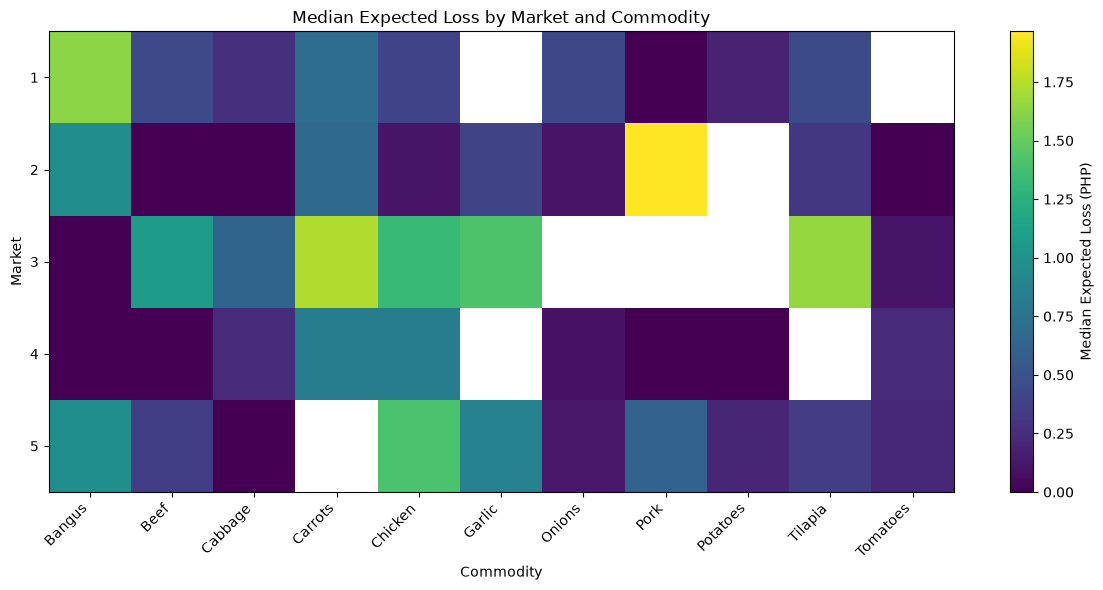


Calibration campaign:
               campaign       date
0  Calibration Campaign 2026-07-01

30 days before calibration:
(4, 17)

30 days after calibration:
(5, 17)


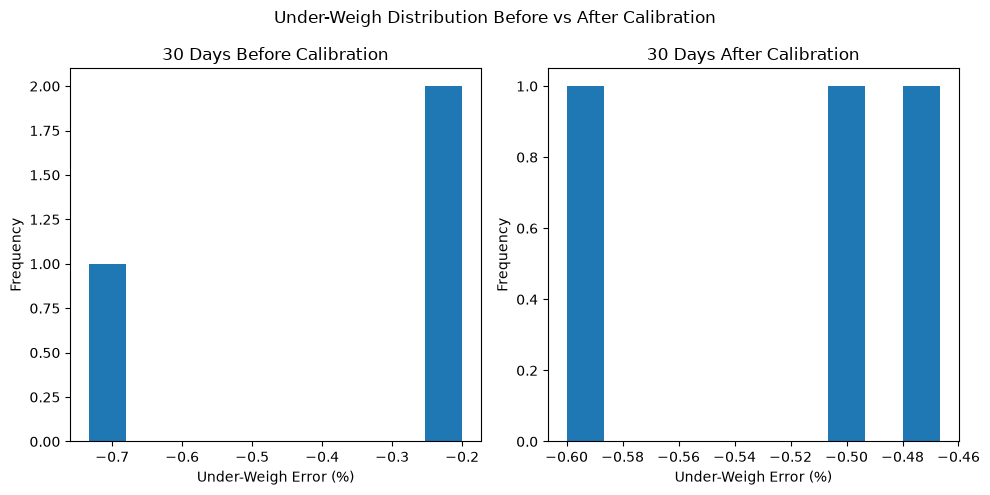

In [20]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

inspections = pd.read_csv("inspections.csv")
prices = pd.read_csv("prices.csv")
sales_samples = pd.read_csv("sales_samples.csv")

print("Inspections:", inspections.shape)
print("Prices:", prices.shape)
print("Sales samples:", sales_samples.shape)

inspections["date"] = pd.to_datetime(inspections["date"])
prices["date"] = pd.to_datetime(prices["date"])
sales_samples["date"] = pd.to_datetime(sales_samples["date"])

inspections.sort_values("date", inplace=True)
prices.sort_values("date", inplace=True)
sales_samples.sort_values("date", inplace=True)

inspections_sales_merge = pd.merge_asof(
    sales_samples,
    inspections,
    on="date",
    by=["stall_id", "market_id"],
    direction="nearest",
    tolerance=pd.Timedelta("7 days")
)

all_merge = pd.merge_asof(
    inspections_sales_merge,
    prices,
    on="date",
    by=["market_id", "commodity"],
    direction="backward",
    tolerance=pd.Timedelta("7 days")
)

all_merge["loss_php"] = (
    np.maximum(
        0,
        all_merge["label_weight_kg"]
        - all_merge["actual_weight_kg"]
    )
    * all_merge["avg_price_per_kg"]
)

all_merge["is_under_weigh"] = (
    all_merge["actual_weight_kg"]
    < all_merge["label_weight_kg"]
)

all_merge["error_weight_perc"] = (
    (
        all_merge["actual_weight_kg"]
        - all_merge["label_weight_kg"]
    )
    / all_merge["label_weight_kg"]
) * 100

rollingrate = (
    all_merge
    .set_index("date")
    .sort_index()
)

market_rolling_rate = (
    rollingrate
    .groupby("market_id")["is_under_weigh"]
    .rolling("14D")
    .mean()
)

markets = sorted(all_merge["market_id"].unique())

plt.figure(figsize=(10, 6))

for market in markets:

    market_data = market_rolling_rate[market]

    plt.plot(
        market_data.index,
        market_data.values * 100,
        label="Market " + str(market)
    )

plt.xlabel("Date")
plt.ylabel("14-Day Rolling Under-Weigh Rate (%)")
plt.title("14-Day Rolling Under-Weigh Rate by Market")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

loss_table = (
    all_merge
    .groupby(["market_id", "commodity"])["loss_php"]
    .median()
    .unstack()
)

print("\nMedian Expected Loss Table:")
print(loss_table)

loss_values = loss_table.to_numpy()

plt.figure(figsize=(12, 6))

plt.imshow(
    loss_values,
    aspect="auto"
)

plt.colorbar(
    label="Median Expected Loss (PHP)"
)

plt.xticks(
    np.arange(len(loss_table.columns)),
    loss_table.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(loss_table.index)),
    loss_table.index
)

plt.xlabel("Commodity")
plt.ylabel("Market")
plt.title("Median Expected Loss by Market and Commodity")

plt.tight_layout()
plt.show()

calibration = pd.DataFrame({
    "campaign": ["Calibration Campaign"],
    "date": [pd.Timestamp("2026-07-01")]
})

calibration_date = calibration["date"][0]

print("\nCalibration campaign:")
print(calibration)

before_data = all_merge[
    (all_merge["date"] >= calibration_date - pd.Timedelta(days=30))
    & (all_merge["date"] < calibration_date)
]

after_data = all_merge[
    (all_merge["date"] > calibration_date)
    & (all_merge["date"] <= calibration_date + pd.Timedelta(days=30))
]

print("\n30 days before calibration:")
print(before_data.shape)

print("\n30 days after calibration:")
print(after_data.shape)

before_under = before_data[
    before_data["is_under_weigh"]
]["error_weight_perc"]

after_under = after_data[
    after_data["is_under_weigh"]
]["error_weight_perc"]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

# Before calibration
axes[0].hist(
    before_under,
    bins=10
)

axes[0].set_title(
    "30 Days Before Calibration"
)

axes[0].set_xlabel(
    "Under-Weigh Error (%)"
)

axes[0].set_ylabel(
    "Frequency"
)


# After calibration
axes[1].hist(
    after_under,
    bins=10
)

axes[1].set_title(
    "30 Days After Calibration"
)

axes[1].set_xlabel(
    "Under-Weigh Error (%)"
)

axes[1].set_ylabel(
    "Frequency"
)


fig.suptitle(
    "Under-Weigh Distribution Before vs After Calibration"
)

plt.tight_layout()
plt.show()


# Task assignment

Member 1: Josef Jayden Nepomuceno - Dataset Generation: Created & generated inspections.csv & prices.csv

Member 2: Eivrard Seraphim Franco - Dataset Generation: Created & generated sales_samples.csv

Member 3: Ralph Aron Bonifacio - Performed Part A — NumPy: Measurement Error & Risk Flags

Member 4: Zachary Matthew Medallon - Performed Part B — pandas: Linking Errors to Consumer Impact

Member 5: Andrei Karl Dela Cruz -  Performed Part C — Matplotlib: Decision-Maker Visuals
